In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

## 1. Load the data

The path is **relative** to the project root so the notebook is portable.

In [2]:
DATA_PATH = "data/titanic.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from {DATA_PATH}")
df.head()

Loaded 891 rows x 15 columns from data/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Basic inspection

Shape, column names, dtypes, and a numeric + categorical summary.

In [3]:
df.shape

(891, 15)

In [4]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.describe(include=object)

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


## 3. Missing values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report.missing_count > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


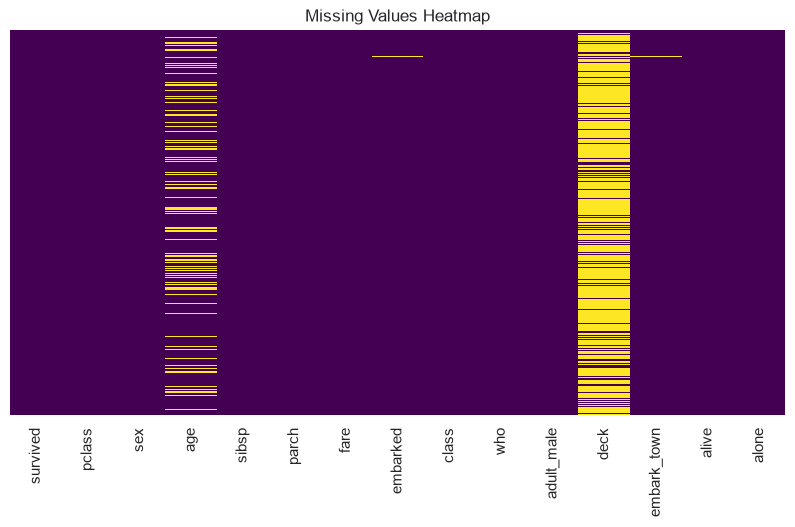

In [9]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
dup_count = df.duplicated().sum()
print(f"Full-row duplicates reported by pandas: {dup_count}")

# Most rows are identical because of the redundant parallel columns. Check duplicates
# after dropping the redundant columns to confirm this hypothesis.
redundant = ["alive", "class", "embark_town"]
df_check = df.drop(columns=redundant)
true_dups = df_check.duplicated().sum()
print(f"Duplicates after dropping {redundant}: {true_dups}")

Full-row duplicates reported by pandas: 107
Duplicates after dropping ['alive', 'class', 'embark_town']: 107


## 5. Univariate analysis

How is each variable distributed on its own?

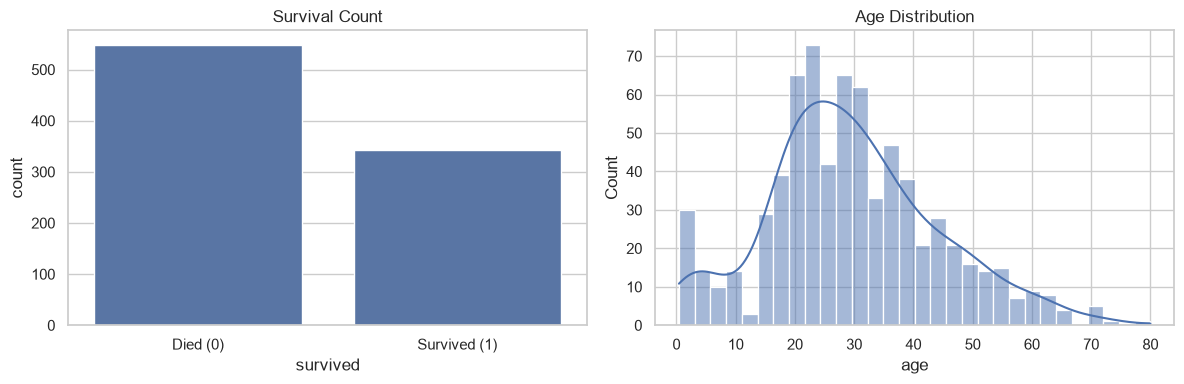

Overall survival rate: 38.38%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="survived", ax=axes[0])
axes[0].set_title("Survival Count")
axes[0].set_xticklabels(["Died (0)", "Survived (1)"])
sns.histplot(df["age"].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Age Distribution")
plt.tight_layout()
plt.show()
print(f"Overall survival rate: {df['survived'].mean():.2%}")

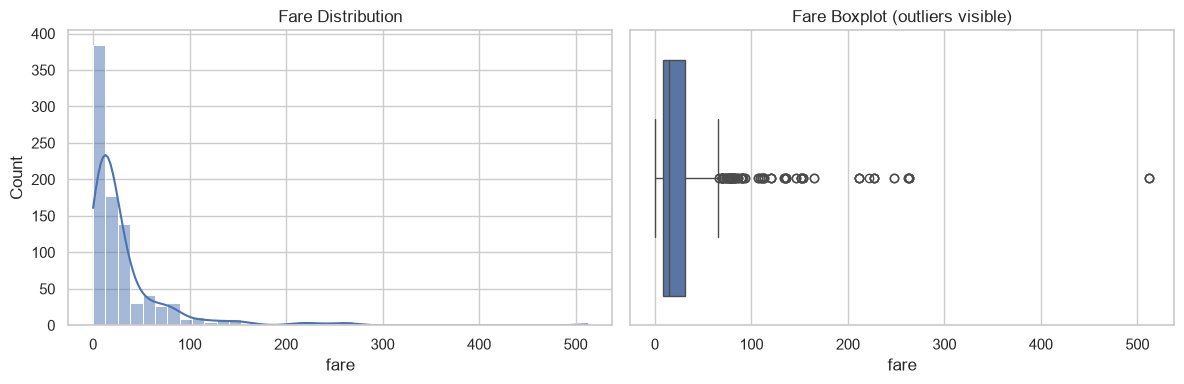

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["fare"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution")
sns.boxplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Fare Boxplot (outliers visible)")
plt.tight_layout()
plt.show()

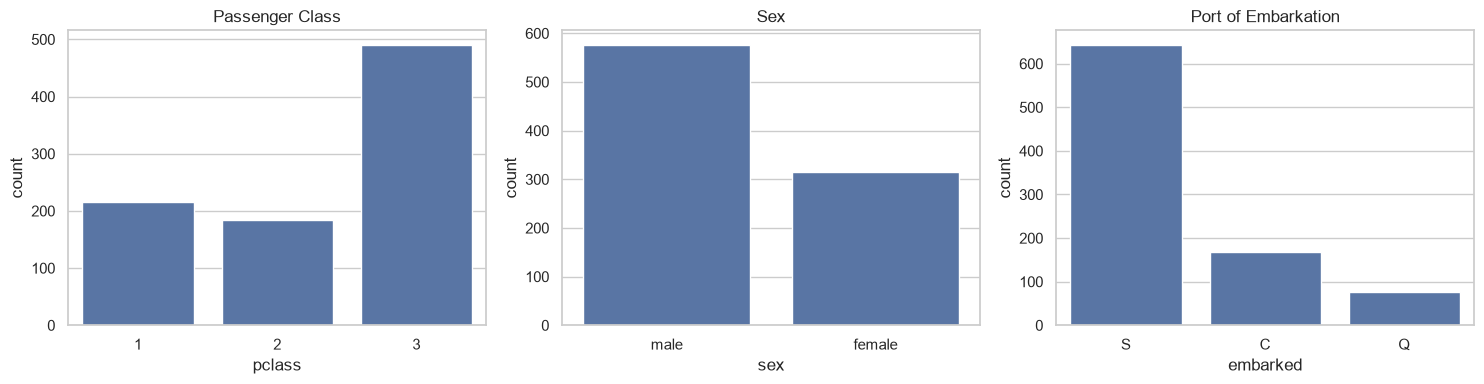

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="pclass", ax=axes[0])
axes[0].set_title("Passenger Class")
sns.countplot(data=df, x="sex", ax=axes[1])
axes[1].set_title("Sex")
sns.countplot(data=df, x="embarked", ax=axes[2])
axes[2].set_title("Port of Embarkation")
plt.tight_layout()
plt.show()

## 6. Bivariate analysis

How does survival relate to each variable?

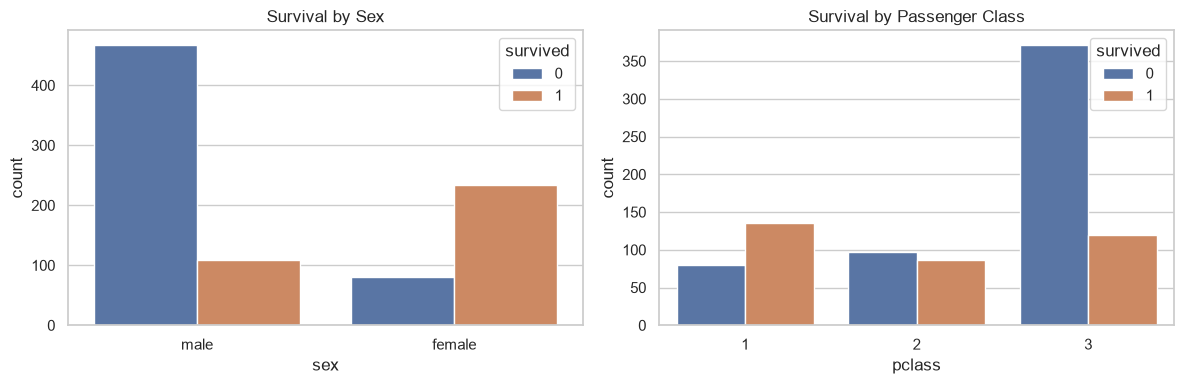

Survival rate by sex:
sex
female    0.742
male      0.189
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="sex", hue="survived", ax=axes[0])
axes[0].set_title("Survival by Sex")
sns.countplot(data=df, x="pclass", hue="survived", ax=axes[1])
axes[1].set_title("Survival by Passenger Class")
plt.tight_layout()
plt.show()

print("Survival rate by sex:")
print(df.groupby("sex")["survived"].mean().round(3))
print("\nSurvival rate by pclass:")
print(df.groupby("pclass")["survived"].mean().round(3))

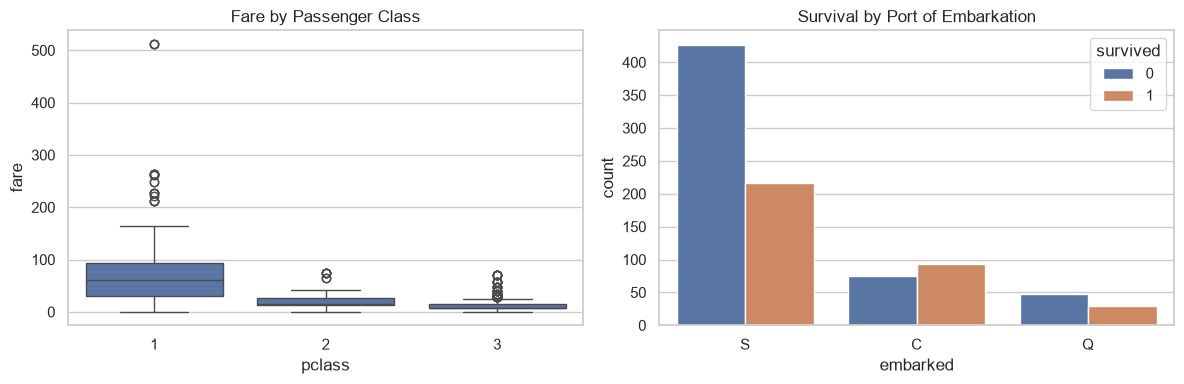

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[0])
axes[0].set_title("Fare by Passenger Class")
sns.countplot(data=df, x="embarked", hue="survived", ax=axes[1])
axes[1].set_title("Survival by Port of Embarkation")
plt.tight_layout()
plt.show()

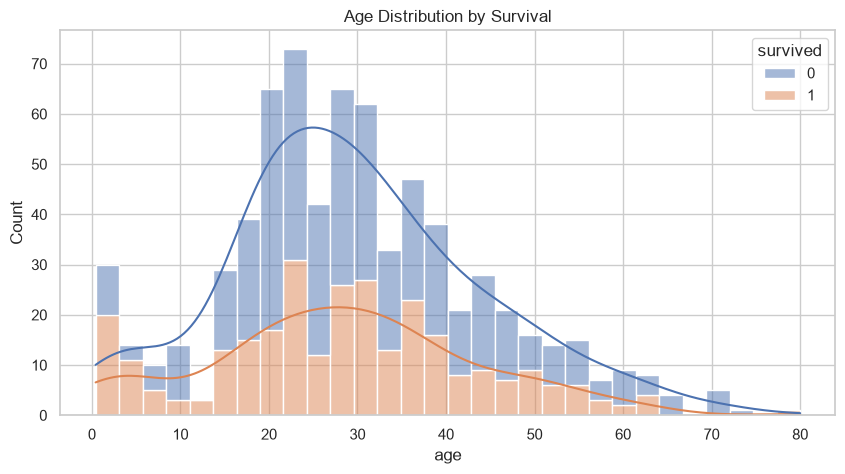

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age", hue="survived", multiple="stack", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

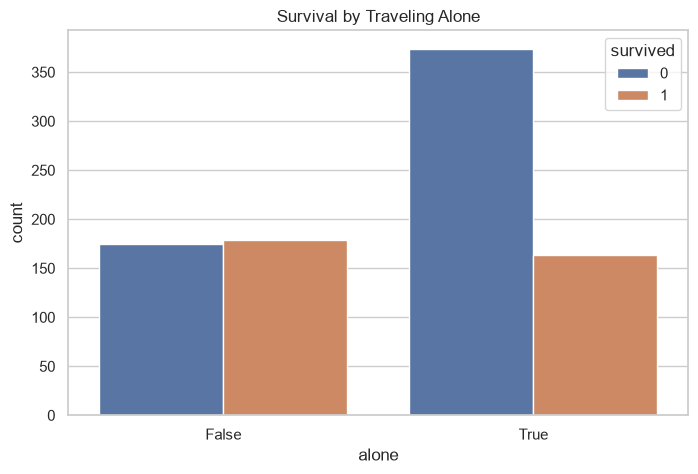

Survival rate by alone:
alone
False    0.506
True     0.304
Name: survived, dtype: float64


In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="alone", hue="survived")
plt.title("Survival by Traveling Alone")
plt.show()
print("Survival rate by alone:")
print(df.groupby("alone")["survived"].mean().round(3))

## 7. Correlation analysis (numeric features)

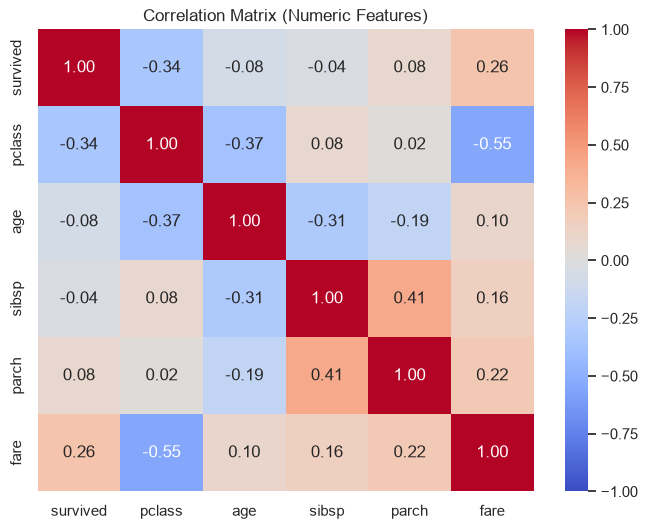

In [18]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

## 8. Data cleaning

Decisions:

- **Drop redundant columns**: `alive` (string form of `survived`), `class` (string form of `pclass`), `embark_town` (string form of `embarked`).
- **Drop `deck`**: 77% missing — too sparse to impute reliably.
- **Drop `adult_male`**: redundant with `sex` + `age`, not useful after engineering.
- **Drop `who`**: redundant with `sex` + `age`.
- **Impute `age`**: median by (`pclass`, `sex`) — accounts for the known correlation between age and class/sex.
- **Drop the 2 rows with missing `embarked`** — too few to impute.

In [19]:
clean = df.copy()

# Drop redundant / sparse columns
clean = clean.drop(columns=["alive", "class", "embark_town", "deck", "adult_male", "who"])

# Drop the 2 rows with missing embarked
clean = clean.dropna(subset=["embarked"]).reset_index(drop=True)

# Impute age with median by (pclass, sex)
age_median = clean.groupby(["pclass", "sex"])["age"].median()

def impute_age(row):
    if pd.isna(row["age"]):
        return age_median.loc[(row["pclass"], row["sex"])]
    return row["age"]

clean["age"] = clean.apply(impute_age, axis=1)

# Drop any remaining full-row duplicates
before = len(clean)
clean = clean.drop_duplicates().reset_index(drop=True)
after = len(clean)
print(f"Rows before drop_duplicates: {before}, after: {after} (removed {before - after})")

print(f"\nClean shape: {clean.shape}")
print(f"Remaining missing values:\n{clean.isnull().sum()[lambda s: s > 0]}")

Rows before drop_duplicates: 889, after: 771 (removed 118)

Clean shape: (771, 9)
Remaining missing values:
Series([], dtype: int64)


## 9. Feature engineering

In [20]:
# Family size and travel-alone flag
clean["family_size"] = clean["sibsp"] + clean["parch"] + 1
clean["is_alone"] = (clean["family_size"] == 1).astype(int)

# Age bands for grouped analysis
bins = [0, 12, 18, 35, 55, 100]
labels = ["child", "teen", "young_adult", "adult", "senior"]
clean["age_band"] = pd.cut(clean["age"], bins=bins, labels=labels)

print("Survival rate by age_band:")
print(clean.groupby("age_band", observed=False)["survived"].mean().round(3))
print("\nSurvival rate by family_size:")
print(clean.groupby("family_size")["survived"].mean().round(3))

Survival rate by age_band:
age_band
child          0.574
teen           0.448
young_adult    0.406
adult          0.386
senior         0.289
Name: survived, dtype: float64

Survival rate by family_size:
family_size
1     0.339
2     0.549
3     0.574
4     0.714
5     0.231
6     0.136
7     0.333
8     0.000
11    0.000
Name: survived, dtype: float64


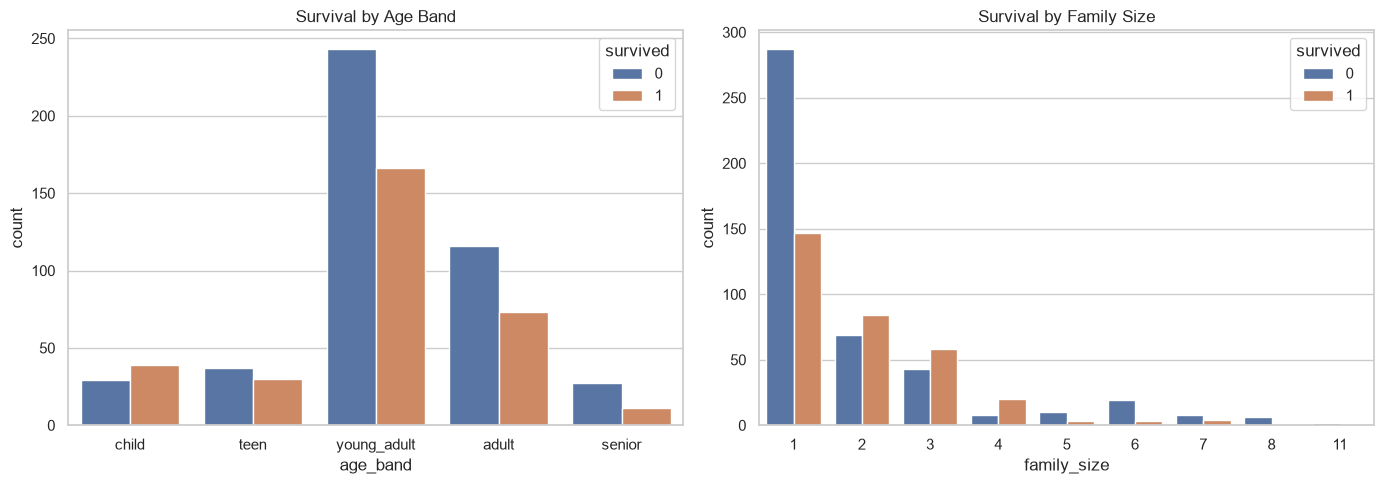

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=clean, x="age_band", hue="survived", ax=axes[0])
axes[0].set_title("Survival by Age Band")
sns.countplot(data=clean, x="family_size", hue="survived", ax=axes[1])
axes[1].set_title("Survival by Family Size")
plt.tight_layout()
plt.show()

## 10. Save cleaned dataset

In [22]:
OUT_PATH = "data/titanic_clean.csv"
clean.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned dataset to {OUT_PATH} ({clean.shape[0]} rows x {clean.shape[1]} cols)")

Saved cleaned dataset to data/titanic_clean.csv (771 rows x 12 cols)


## 11. Summary of findings

- **Sex** is the strongest single predictor of survival. Female passengers survived at roughly **3-4x** the rate of male passengers.
- **Passenger class** strongly affects survival: 1st class ≈ 63%, 2nd class ≈ 47%, 3rd class ≈ 24%.
- **Fare** is positively correlated with survival (correlated with class).
- **Children** had higher survival rates than adult males.
- **Traveling alone** slightly reduced survival odds.
- The **deck** column was dropped (77% missing). **Age** was imputed using the median within (`pclass`, `sex`) groups. **Embarked** had 2 missing rows that were dropped.
- Engineered features: `family_size`, `is_alone`, `age_band`.

The cleaned dataset (`data/titanic_clean.csv`) is ready for modeling in `02_modeling.ipynb`.